# 지형 특성별 산불 발생 EDA

산불 발생 지점이 어떤 지형 특성에 많이 분포하는지 확인합니다.

분석 질문:
- 경사도가 높은 곳에서 더 많이 발생하는가?
- 남향/남서향 같은 특정 사면방향에서 더 자주 발생하는가?
- 특정 고도 구간에 산불 발생 지점이 집중되는가?

주의: 이 데이터는 산불 발생 지점만 포함하므로, 전체 지형 면적 대비 발생 확률이 아니라 발생 지점의 분포를 해석합니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
DATA_PATH = ROOT / "data" / "processed" / "산불발생위치도_지형특성계산.csv"
OUT_DIR = ROOT / "outputs" / "terrain_eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/project/weather-bigdata-project/data/processed/산불발생위치도_지형특성계산.csv')

## 1. 데이터 로드 및 기본 확인

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(25036, 9)


,fire_id,위도,경도,고도(m),경사도(도),사면방향_sin,사면방향_cos,TPI(지형위치지수),TWI(지형다습지수)
0,F_000000,37.635100,126.997582,233.925380,19.854153,-0.998277,-0.058677,-2.599762,5.503641
1,F_000001,37.450793,127.069168,121.872080,8.362768,0.059167,-0.998248,1.706253,2.001579
2,F_000002,37.681290,127.016965,274.507260,17.241868,-0.874421,0.485168,0.766327,1.479498
3,F_000003,37.502707,127.147636,39.532635,5.510313,-0.429893,0.902880,0.180145,2.706372
4,F_000004,37.617382,127.037494,76.686935,11.763594,0.932967,0.359961,-0.172913,1.381019


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25036 entries, 0 to 25035
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fire_id      25036 non-null  str    
 1   위도           25036 non-null  float64
 2   경도           25036 non-null  float64
 3   고도(m)        25036 non-null  float64
 4   경사도(도)       25036 non-null  float64
 5   사면방향_sin     25036 non-null  float64
 6   사면방향_cos     25036 non-null  float64
 7   TPI(지형위치지수)  25036 non-null  float64
 8   TWI(지형다습지수)  23182 non-null  float64
dtypes: float64(8), str(1)
memory usage: 1.7 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
위도,25036.0,3.656868e+01,1.096221e+00,33.226835,35.673609,36.573791,37.502494,3.913942e+01
경도,25036.0,1.278702e+02,8.756040e-01,124.666241,127.094735,127.840009,128.616990,1.309100e+02
고도(m),25036.0,1.791273e+02,1.743158e+02,0.000000,53.101670,125.079200,245.591088,1.643591e+03
경사도(도),25036.0,8.114909e+00,6.676965e+00,0.000000,2.698098,6.417335,12.046538,4.301952e+01
사면방향_sin,25036.0,-3.325463e-02,7.284258e-01,-1.000000,-0.792517,-0.062320,0.706597,1.000000e+00
사면방향_cos,25036.0,1.584581e-01,6.657477e-01,-1.000000,-0.400409,0.222959,0.805226,1.000000e+00
TPI(지형위치지수),25036.0,-4.098851e-01,4.487153e+00,-27.624725,-2.595881,-0.569099,1.107859,4.566284e+01
TWI(지형다습지수),23182.0,2.095722e+08,5.420258e+08,0.635877,2.912494,4.186767,6.477516,1.611377e+09


## 2. 사면방향 복원

`사면방향_sin`, `사면방향_cos`를 각도로 복원한 뒤 8방위로 구분합니다.

In [5]:
aspect_order = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
aspect_labels_ko = {
    "N": "북향",
    "NE": "북동향",
    "E": "동향",
    "SE": "남동향",
    "S": "남향",
    "SW": "남서향",
    "W": "서향",
    "NW": "북서향",
}

df["사면방향(도)"] = (
    np.degrees(np.arctan2(df["사면방향_sin"], df["사면방향_cos"])) + 360
) % 360

bins = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"]

df["사면방향"] = pd.cut(
    df["사면방향(도)"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,
    ordered=False,
)
df["사면방향_한글"] = df["사면방향"].map(aspect_labels_ko)

df[["사면방향_sin", "사면방향_cos", "사면방향(도)", "사면방향", "사면방향_한글"]].head()

,사면방향_sin,사면방향_cos,사면방향(도),사면방향,사면방향_한글
0,-0.998277,-0.058677,266.636139,W,서향
1,0.059167,-0.998248,176.607990,S,남향
2,-0.874421,0.485168,299.023452,NW,북서향
3,-0.429893,0.902880,334.539251,NW,북서향
4,0.932967,0.359961,68.902175,E,동향


## 3. 경사도와 고도 분포

산불 발생 지점의 경사도와 고도가 어느 구간에 많이 몰려 있는지 확인합니다.

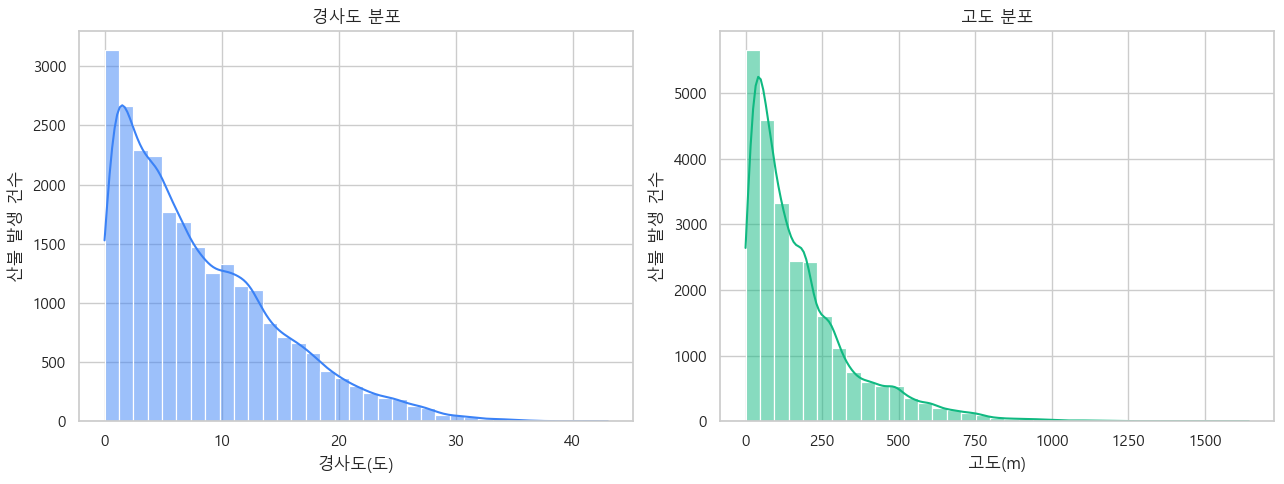

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["경사도(도)"], bins=35, kde=True, ax=axes[0], color="#3b82f6")
axes[0].set_title("경사도 분포")
axes[0].set_xlabel("경사도(도)")
axes[0].set_ylabel("산불 발생 건수")

sns.histplot(df["고도(m)"], bins=35, kde=True, ax=axes[1], color="#10b981")
axes[1].set_title("고도 분포")
axes[1].set_xlabel("고도(m)")
axes[1].set_ylabel("산불 발생 건수")

plt.tight_layout()
plt.savefig(OUT_DIR / "notebook_slope_elevation_hist.png", dpi=160)
plt.show()

In [7]:
slope_summary = pd.Series({
    "평균 경사도": df["경사도(도)"].mean(),
    "중앙값 경사도": df["경사도(도)"].median(),
    "경사도 15도 이상 건수": (df["경사도(도)"] >= 15).sum(),
    "경사도 15도 이상 비율(%)": (df["경사도(도)"] >= 15).mean() * 100,
    "경사도 25도 이상 건수": (df["경사도(도)"] >= 25).sum(),
    "경사도 25도 이상 비율(%)": (df["경사도(도)"] >= 25).mean() * 100,
})

elevation_summary = pd.Series({
    "평균 고도": df["고도(m)"].mean(),
    "중앙값 고도": df["고도(m)"].median(),
    "고도 300m 미만 건수": (df["고도(m)"] < 300).sum(),
    "고도 300m 미만 비율(%)": (df["고도(m)"] < 300).mean() * 100,
})

pd.concat([slope_summary, elevation_summary]).round(2)

평균 경사도                  8.11
중앙값 경사도                 6.42
경사도 15도 이상 건수        3979.00
경사도 15도 이상 비율(%)       15.89
경사도 25도 이상 건수         556.00
경사도 25도 이상 비율(%)        2.22
평균 고도                 179.13
중앙값 고도                125.08
고도 300m 미만 건수       20537.00
고도 300m 미만 비율(%)       82.03
dtype: float64

## 4. 사면방향별 산불 발생 빈도

8방위 기준으로 어느 방향의 사면에서 산불 발생 지점이 많이 나타나는지 확인합니다.

In [8]:
aspect_counts = (
    df["사면방향"]
    .value_counts()
    .reindex(aspect_order)
    .rename_axis("aspect")
    .reset_index(name="count")
)
aspect_counts["percent"] = aspect_counts["count"] / aspect_counts["count"].sum() * 100
aspect_counts["label_ko"] = aspect_counts["aspect"].map(aspect_labels_ko)
aspect_counts

,aspect,count,percent,label_ko
0,N,4099,16.372424,북향
1,NE,3601,14.383288,북동향
2,E,3337,13.328807,동향
3,SE,2185,8.727432,남동향
4,S,1991,7.952548,남향
5,SW,2407,9.614156,남서향
6,W,4083,16.308516,서향
7,NW,3333,13.312830,북서향


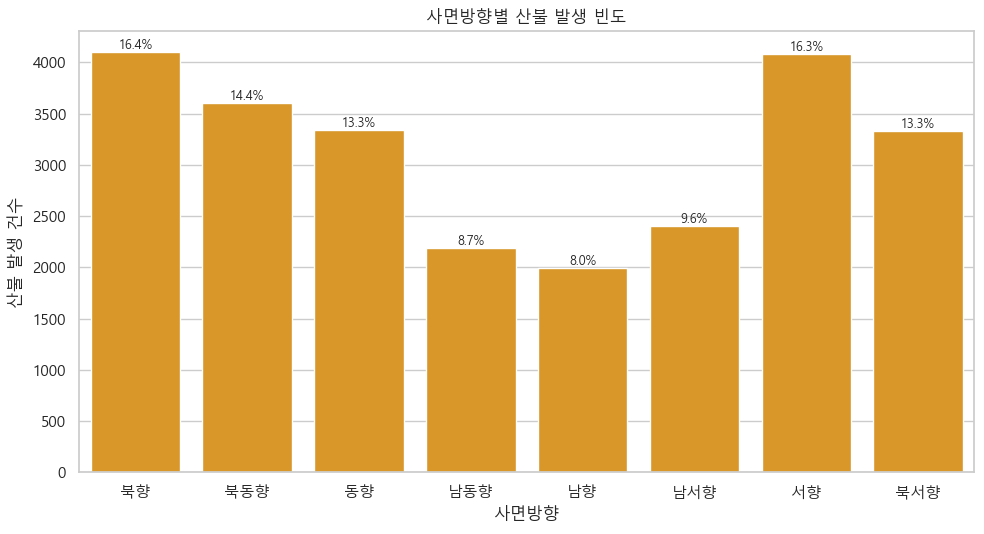

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=aspect_counts, x="label_ko", y="count", ax=ax, color="#f59e0b")
ax.set_title("사면방향별 산불 발생 빈도")
ax.set_xlabel("사면방향")
ax.set_ylabel("산불 발생 건수")

for i, row in aspect_counts.iterrows():
    ax.text(i, row["count"], f"{row['percent']:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "notebook_aspect_frequency.png", dpi=160)
plt.show()

## 5. Boxplot

사면방향별로 경사도와 고도 분포가 달라지는지 확인합니다.

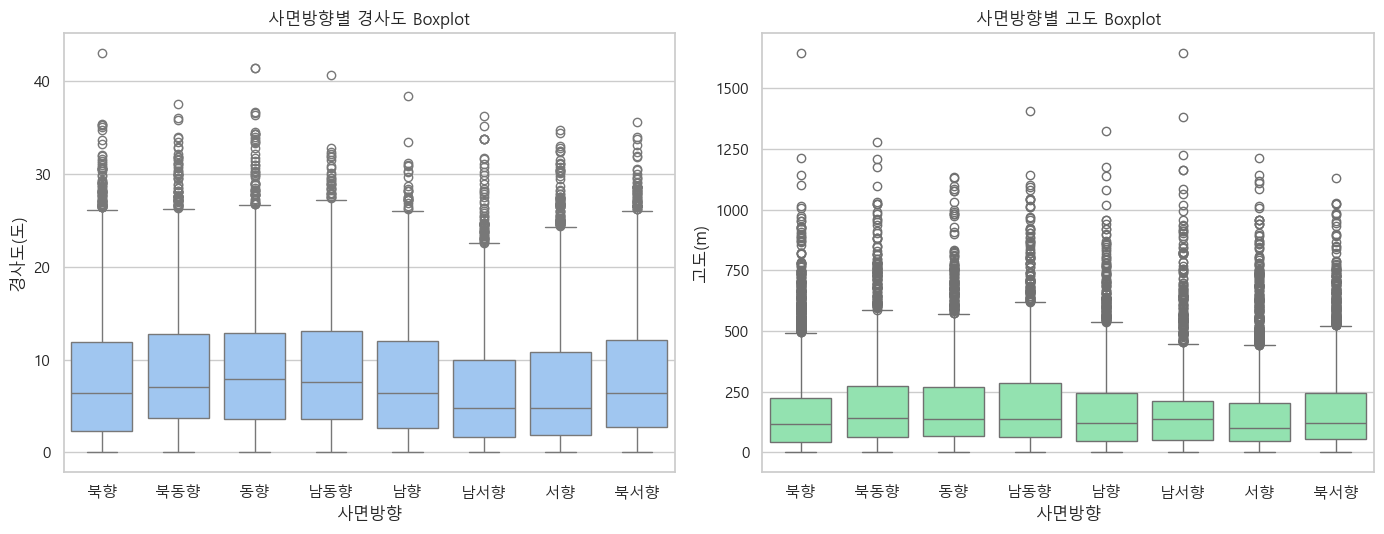

In [10]:
plot_df = df.dropna(subset=["사면방향"]).copy()
plot_df["사면방향"] = pd.Categorical(plot_df["사면방향"], aspect_order, ordered=True)
plot_df["사면방향_한글"] = plot_df["사면방향"].map(aspect_labels_ko)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.boxplot(data=plot_df, x="사면방향_한글", y="경사도(도)", ax=axes[0], color="#93c5fd")
axes[0].set_title("사면방향별 경사도 Boxplot")
axes[0].set_xlabel("사면방향")
axes[0].set_ylabel("경사도(도)")

sns.boxplot(data=plot_df, x="사면방향_한글", y="고도(m)", ax=axes[1], color="#86efac")
axes[1].set_title("사면방향별 고도 Boxplot")
axes[1].set_xlabel("사면방향")
axes[1].set_ylabel("고도(m)")

plt.tight_layout()
plt.savefig(OUT_DIR / "notebook_aspect_boxplots.png", dpi=160)
plt.show()

## 6. 고도-경사도 구간별 산불 발생 빈도

고도와 경사도를 함께 구간화하여 어떤 조합에서 발생 지점이 많은지 확인합니다.

In [11]:
slope_bins = [0, 5, 10, 15, 20, 25, 30, 35, 45]
elev_bins = [0, 50, 100, 200, 300, 500, 800, 1200, 1800]

df["경사도구간"] = pd.cut(df["경사도(도)"], slope_bins, right=False)
df["고도구간"] = pd.cut(df["고도(m)"], elev_bins, right=False)

slope_elev_table = pd.crosstab(df["고도구간"], df["경사도구간"])
slope_elev_table

경사도구간,"[0, 5)","[5, 10)","[10, 15)","[15, 20)","[20, 25)","[25, 30)","[30, 35)","[35, 45)"
고도구간,,,,,,,,
"[0, 50)",4461,1139,273,50,7,1,0,0
"[50, 100)",2317,1466,713,238,63,8,0,0
"[100, 200)",2314,1832,1346,598,215,57,6,1
"[200, 300)",751,921,885,547,231,72,23,2
"[300, 500)",474,542,794,577,318,143,37,8
"[500, 800)",174,250,331,289,184,126,29,5
"[800, 1200)",7,24,41,54,48,23,9,2
"[1200, 1800)",0,1,1,3,1,3,1,0


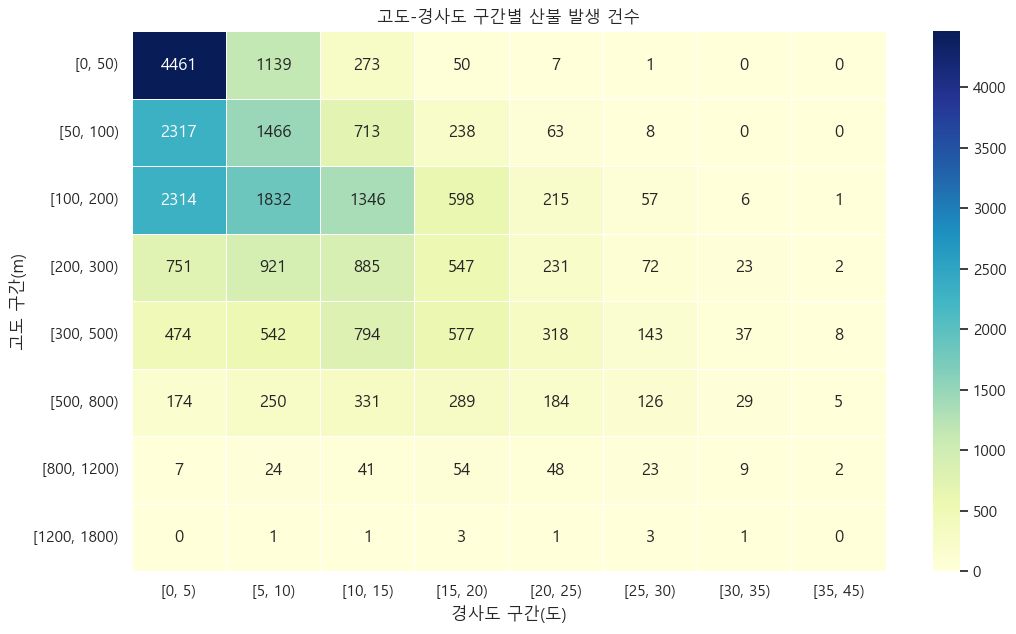

In [12]:
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(slope_elev_table, cmap="YlGnBu", annot=True, fmt="d", linewidths=0.4, ax=ax)
ax.set_title("고도-경사도 구간별 산불 발생 건수")
ax.set_xlabel("경사도 구간(도)")
ax.set_ylabel("고도 구간(m)")
plt.tight_layout()
plt.savefig(OUT_DIR / "notebook_slope_elevation_heatmap.png", dpi=160)
plt.show()

## 7. TPI / TWI 분포

- TPI: 주변보다 높은 능선/낮은 계곡 등 지형 위치 특성
- TWI: 지형적 습윤도 지수

TWI는 일부 비정상적으로 큰 값이 있어 시각화에서는 0~30 범위만 표시합니다.

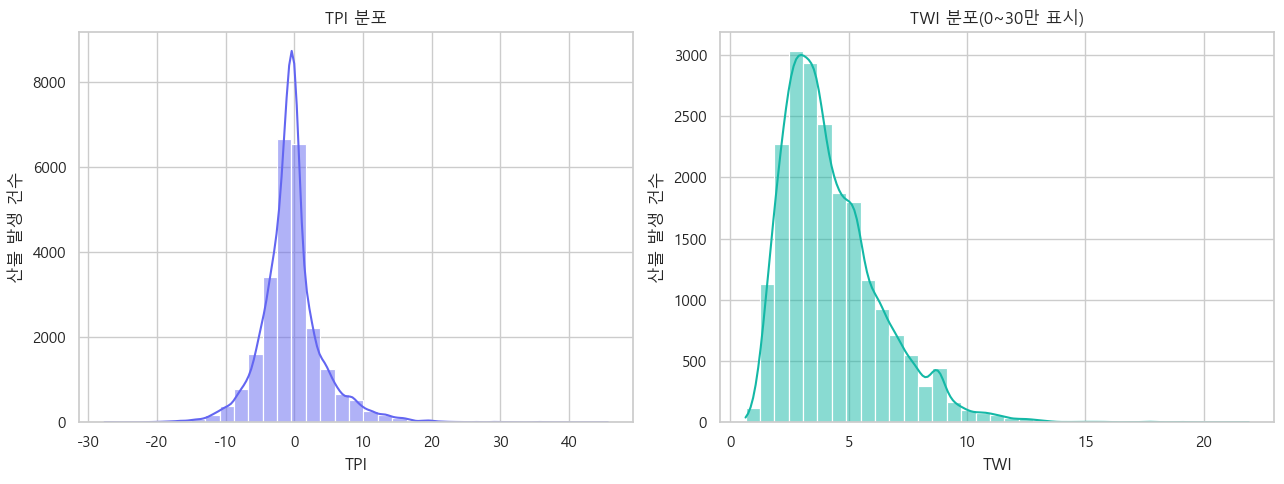

In [13]:
df["TWI_시각화용"] = df["TWI(지형다습지수)"].where(df["TWI(지형다습지수)"].between(0, 30))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["TPI(지형위치지수)"].dropna(), bins=35, kde=True, ax=axes[0], color="#6366f1")
axes[0].set_title("TPI 분포")
axes[0].set_xlabel("TPI")
axes[0].set_ylabel("산불 발생 건수")

sns.histplot(df["TWI_시각화용"].dropna(), bins=35, kde=True, ax=axes[1], color="#14b8a6")
axes[1].set_title("TWI 분포(0~30만 표시)")
axes[1].set_xlabel("TWI")
axes[1].set_ylabel("산불 발생 건수")

plt.tight_layout()
plt.savefig(OUT_DIR / "notebook_tpi_twi_hist.png", dpi=160)
plt.show()

## 8. 인사이트 정리

In [14]:
def interval_text(interval):
    return f"{interval.left:g}~{interval.right:g}"

n = len(df)
top_aspect = aspect_counts.sort_values("count", ascending=False).iloc[0]
top_cell = slope_elev_table.stack().idxmax()

insights = [
    f"분석 대상 산불 발생 지점은 총 {n:,}건입니다.",
    f"평균 경사도는 {df['경사도(도)'].mean():.1f}도, 중앙값은 {df['경사도(도)'].median():.1f}도입니다.",
    f"경사도 25도 이상 지점은 {(df['경사도(도)'] >= 25).sum():,}건({(df['경사도(도)'] >= 25).mean() * 100:.1f}%)입니다.",
    f"평균 고도는 {df['고도(m)'].mean():.1f}m, 중앙값은 {df['고도(m)'].median():.1f}m입니다.",
    f"고도 300m 미만 지점은 {(df['고도(m)'] < 300).sum():,}건({(df['고도(m)'] < 300).mean() * 100:.1f}%)입니다.",
    f"사면방향 중 가장 많은 방향은 {aspect_labels_ko[top_aspect['aspect']]}({top_aspect['count']:,}건, {top_aspect['percent']:.1f}%)입니다.",
    f"고도-경사도 조합에서는 고도 {interval_text(top_cell[0])}m, 경사도 {interval_text(top_cell[1])}도 구간이 가장 많습니다.",
]

for insight in insights:
    print("- " + insight)

- 분석 대상 산불 발생 지점은 총 25,036건입니다.
- 평균 경사도는 8.1도, 중앙값은 6.4도입니다.
- 경사도 25도 이상 지점은 556건(2.2%)입니다.
- 평균 고도는 179.1m, 중앙값은 125.1m입니다.
- 고도 300m 미만 지점은 20,537건(82.0%)입니다.
- 사면방향 중 가장 많은 방향은 북향(4,099건, 16.4%)입니다.
- 고도-경사도 조합에서는 고도 0~50m, 경사도 0~5도 구간이 가장 많습니다.


### 보고서에 쓸 수 있는 문장

- 산불 발생 지점은 평균 경사도 약 8도, 중앙값 약 6도 수준으로 완만한~중간 경사지에 많이 분포했다.
- 고도는 300m 미만 지점이 대부분을 차지해, 분석 데이터에서는 저고도 산불 발생 지점이 우세했다.
- 사면방향은 북향과 서향에서 가장 많은 발생 건수를 보였다.
- 다만 본 분석은 산불 발생 지점만 대상으로 하므로, 특정 지형이 실제로 더 위험한지 판단하려면 비발생 지점 또는 전체 산림 지형 면적과 함께 비교해야 한다.